Current working directory:
/home/aluoch/smart-waste-classifier/notebooks
Found 12259 files belonging to 10 classes.
Using 9808 files for training.
Found 12259 files belonging to 10 classes.
Using 2451 files for validation.


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 61s 177ms/step - accuracy: 0.4267 - loss: 1.6306 - val_accuracy: 0.5284 - val_loss: 1.3503
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 57s 186ms/step - accuracy: 0.5991 - loss: 1.1773 - val_accuracy: 0.6116 - val_loss: 1.1493
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 58s 189ms/step - accuracy: 0.6789 - loss: 0.9284 - val_accuracy: 0.6377 - val_loss: 1.0855
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 56s 181ms/step - accuracy: 0.7561 - loss: 0.7142 - val_accuracy: 0.6397 - val_loss: 1.2287
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.8226 - loss: 0.5325 - val_accuracy: 0.6332 - val_loss: 1.2474
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 56s 184ms/step - accuracy: 0.8835 - loss: 0.3498 - val_accuracy: 0.6479 - val_loss: 1.3967
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 56s 182ms/step - accuracy: 0.9216 - loss: 0.2424 - val_accuracy: 0.6516 - val_loss: 1.5310
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 63s 205ms/step - accuracy: 0.9446 - loss: 0

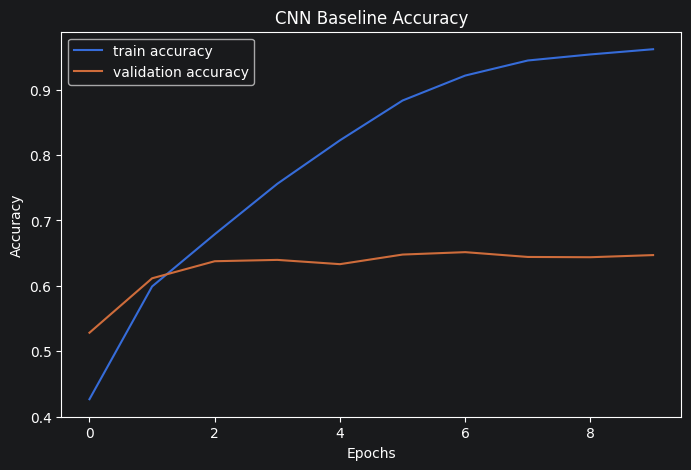

Saved baseline loss figure successfully!


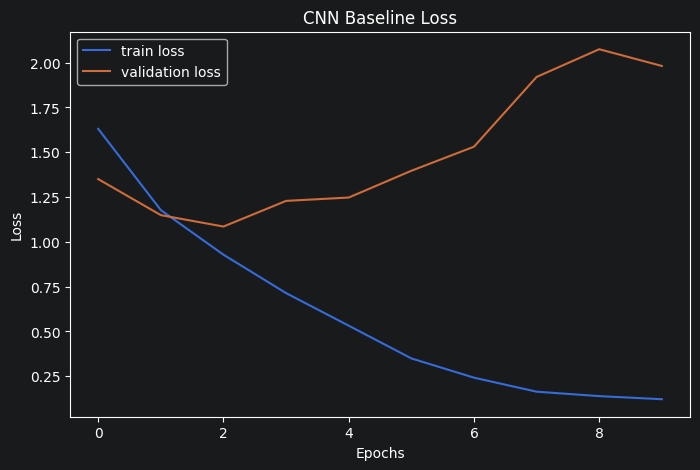

CNN baseline model saved successfully!


In [10]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("Current working directory:")
print(os.getcwd())

# Dataset loading
data_dir = "../data/standardized_256"

img_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Create output folders
os.makedirs("../models", exist_ok=True)
os.makedirs("../images", exist_ok=True)

# Build CNN model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.title("CNN Baseline Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../images/cnn_baseline_accuracy.png")
print("Saved baseline accuracy image successfully!")

plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.title("CNN Baseline Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../images/cnn_baseline_loss.png")
print("Saved baseline loss figure successfully!")

plt.show()

# Save model
model.save("../models/cnn_baseline.keras")
print("CNN baseline model saved successfully!")